<a href="https://colab.research.google.com/github/spacepirate07/Probabilidad-/blob/main/ProyectoFinalU6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Proyecto Final: Analisis Estadistico de Datos COVID-19 en Python**
###**Probabilidad y Estadistica**
###**Grupo 2YY**
###**Periodo:** Enero-Junio 2026
###**Fecha de entrega:** 25 de mayo del 2026
###**Alumno:** Erick Daniel Galarza Garcia
###**Docente:** Jose Gabriel Rodriguez Rivas
###**Unidad 6**

In [1]:
from google.colab import drive
from matplotlib import pyplot
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("/content/drive/MyDrive/covid2020-2021-codificado.csv")

/tmp/ipykernel_28572/1683264884.py:5: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/content/drive/MyDrive/covid2020-2021-codificado.csv")


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12634194 entries, 0 to 12634193
Data columns (total 21 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   SECTOR              object
 1   SEXO                object
 2   ENTIDAD_NAC         object
 3   TIPO_PACIENTE       object
 4   FECHA_INGRESO       object
 5   FECHA_DEF           object
 6   INTUBADO            object
 7   NEUMONIA            object
 8   EDAD                int64 
 9   EMBARAZO            object
 10  INDIGENA            object
 11  DIABETES            object
 12  EPOC                object
 13  ASMA                object
 14  HIPERTENSION        object
 15  CARDIOVASCULAR      object
 16  OBESIDAD            object
 17  RENAL_CRONICA       object
 18  TABAQUISMO          object
 19  RESULTADO_ANTIGENO  object
 20  UCI                 object
dtypes: int64(1), object(20)
memory usage: 2.0+ GB


In [3]:
df.head()

,SECTOR,SEXO,ENTIDAD_NAC,TIPO_PACIENTE,FECHA_INGRESO,FECHA_DEF,INTUBADO,NEUMONIA,EDAD,EMBARAZO,...,DIABETES,EPOC,ASMA,HIPERTENSION,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,RESULTADO_ANTIGENO,UCI
0,Issste,Femenino,San Luis Potosí,Ambulatorio,2020-12-06,9999-99-99,No aplica,No,55,No,...,Si,No,No,No,No,No,No,No,Pendiente,No aplica
1,Issste,Masculino,San Luis Potosí,Ambulatorio,2020-02-20,9999-99-99,No aplica,No,59,No aplica,...,No,No,No,No,No,No,No,No,Pendiente,No aplica
2,Ssa,Femenino,Jalisco,Ambulatorio,2020-04-22,9999-99-99,No aplica,No,42,No,...,No,No,Si,No,No,No,No,No,Pendiente,No aplica
3,Ssa,Masculino,Chihuahua,Ambulatorio,2020-07-28,9999-99-99,No aplica,No,35,No aplica,...,No,No,No,No,No,No,No,No,Pendiente,No aplica
4,Ssa,Masculino,Ciudad De México,Ambulatorio,2020-08-18,9999-99-99,No aplica,No,51,No aplica,...,No,No,No,Si,No,No,No,No,Pendiente,No aplica


In [4]:
print(df['RESULTADO_ANTIGENO'].value_counts()) #usamos value_counts() para contar cuantos registros hay de cada valor de la columna
print(df['TIPO_PACIENTE'].value_counts())
print(df['EMBARAZO'].value_counts())
print(df['INDIGENA'].value_counts())

RESULTADO_ANTIGENO
Negativo     5853547
Pendiente    5005939
Positivo     1774708
Name: count, dtype: int64
TIPO_PACIENTE
Ambulatorio      11543303
Hospitalizado     1090891
Name: count, dtype: int64
EMBARAZO
No                 6483614
No aplica          5985456
Si                  122583
Se ignora            42529
No especificado         12
Name: count, dtype: int64
INDIGENA
No                 3665974
No especificado     167182
Si                   35240
Name: count, dtype: int64


###Numero de casos positivos: **1774708**
###Numero de casos negativos: **5853547**
###Numero de casos pendientes de resultado: **5005939**
###Numero de pacientes hospitalizados: **1090891**
###Numero de pacientes ambulatorios: **11543303**
###Numero de pacientes embarazadas: **122583**
###Numero de pacientes indigenas: **35240**

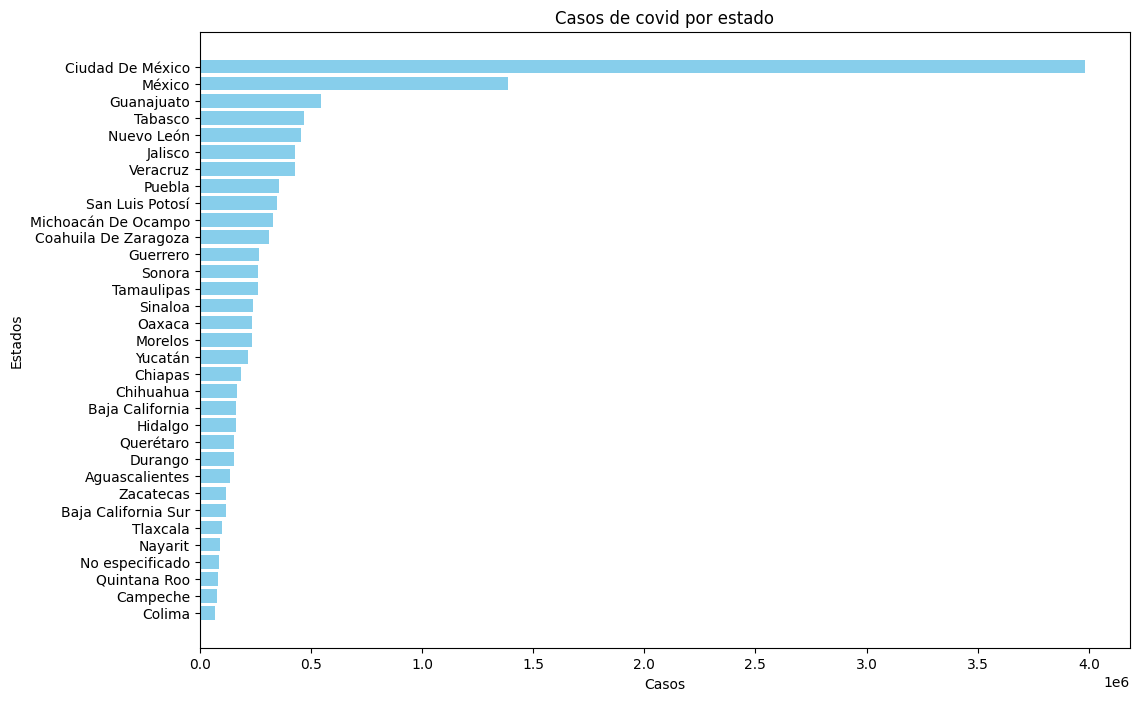

In [5]:
df['ENTIDAD_NAC']=df['ENTIDAD_NAC'].replace({99: 'No especificado', '99':'No especificado'})#replace para sustituir el 99 con no especificado para la grafica
estados=df['ENTIDAD_NAC'].value_counts()#contamos cuantos registros hay por estado
plt.figure(figsize=(12,8))#creacion del lienzo
plt.barh(estados.index[::-1], estados.values[::-1], color='skyblue')#se crea la grafica de barras horizontales, [::-1] para voltear el orden, asi el estado con mas casos queda arriba
plt.title('Casos de covid por estado')
plt.xlabel('Casos')
plt.ylabel('Estados')
plt.show()

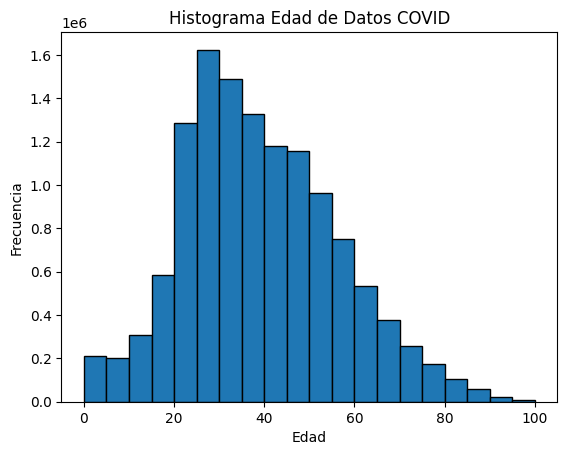

In [6]:
plt.hist(df.EDAD, bins = 20, edgecolor='black', range=(0,100)) #se crea el histograma, se ajusta el rango de 0 a 100 que es un rango normal de edad ya que habia valores muy grandes o mas que debierion ser errores al registrar
plt.title("Histograma Edad de Datos COVID")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

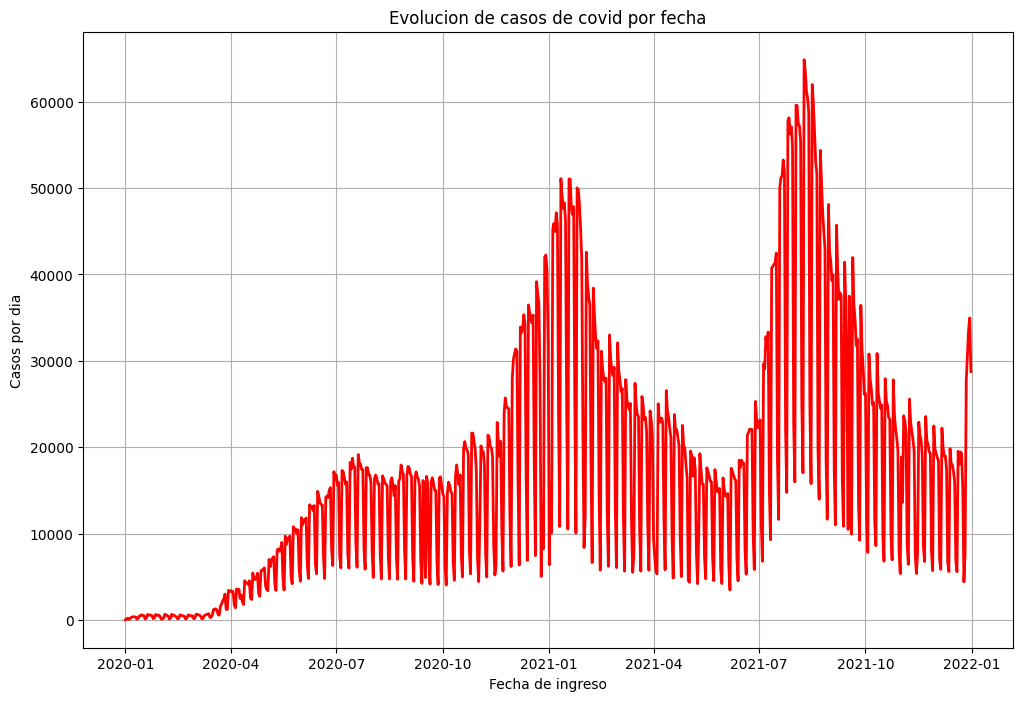

In [7]:
df['FECHA_INGRESO']=pd.to_datetime(df['FECHA_INGRESO'])#conversion a formato de fechas
casosxfecha=df.groupby('FECHA_INGRESO').size() #agrupamos los datos por cada fecha única y contamos cuántas personas ingresaron ese día
plt.figure(figsize=(12,8))
plt.plot(casosxfecha.index, casosxfecha.values, color='red', linewidth=2) #eje x tiene las fechas (index) y el eje y casos por dia (values)
plt.title('Evolucion de casos de covid por fecha')
plt.xlabel('Fecha de ingreso')
plt.ylabel('Casos por dia')
plt.grid(True)
plt.show()
#picos y valles muy altos y bajos respectivamente porque los fines de semana no habia tantos registros de casos como lunes o martes

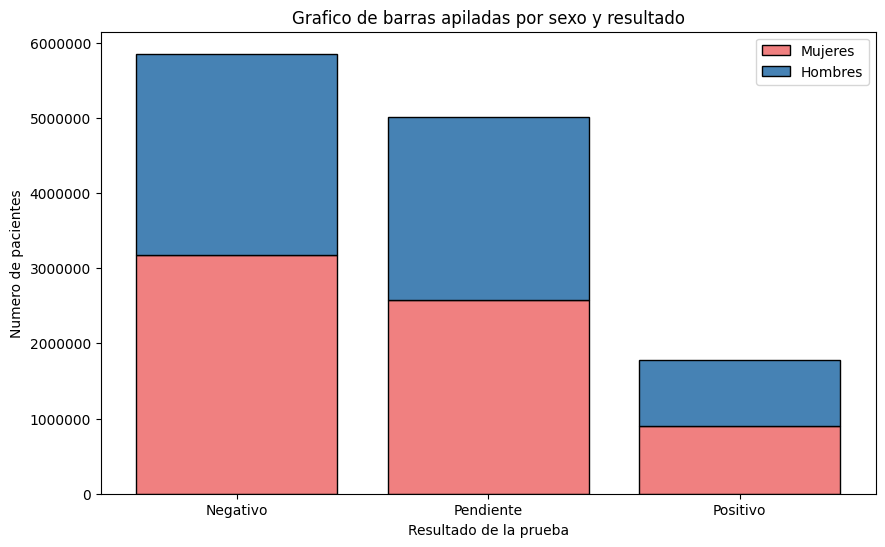

In [8]:
tabla_sexo_resultado=pd.crosstab(df['RESULTADO_ANTIGENO'],df['SEXO'])#Esto calcula cuántos hombres y cuántas mujeres hay por cada tipo de resultado (Negativo, Positivo, Pendiente)
plt.figure(figsize=(10,6))
#primer capa
plt.bar(tabla_sexo_resultado.index,tabla_sexo_resultado['Femenino'],label='Mujeres',color='lightcoral',edgecolor='black')#se dibuja las barras de las mujeres en el fondo, usamos los resultados como el eje x (tabla_sexo_resultado.index) y los datos de 'Femenino' para la altura
#segunda capa, se dibujan las barras de los hombres encima de las de las mujeres, esto lo hace el 'bottom=tabla_sexo_resultado['Femenino']', que le dice a python: "empieza a dibujar desde donde terminaron las barras de las mujeres"
plt.bar(tabla_sexo_resultado.index,tabla_sexo_resultado['Masculino'],bottom=tabla_sexo_resultado['Femenino'],label='Hombres',color='steelblue',edgecolor='black')
plt.title('Grafico de barras apiladas por sexo y resultado')
plt.xlabel('Resultado de la prueba')
plt.ylabel('Numero de pacientes')
plt.ticklabel_format(style='plain', axis='y')#quitar notacion cientifica
plt.legend()
plt.show()

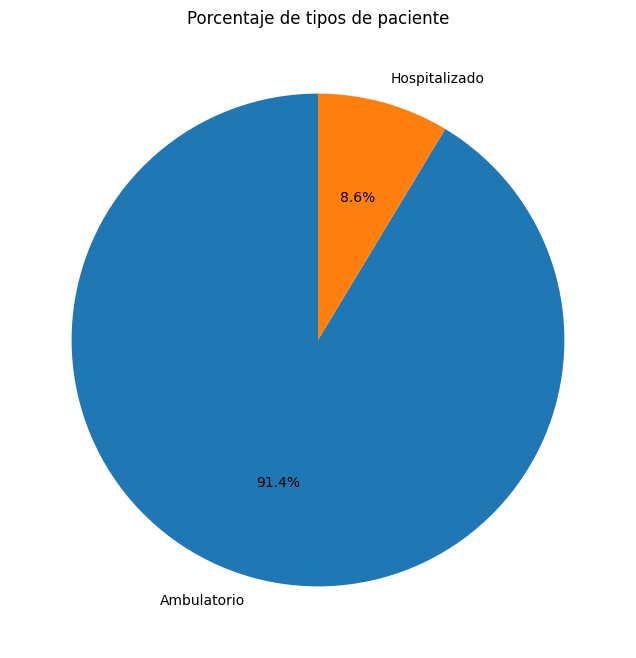

[11543303  1090891]


In [16]:
cantidad_tipos=df['TIPO_PACIENTE'].value_counts()
plt.figure(figsize=(8,8))
#'cantidad_tipos.values' le da el tamaño a las rebanadas (los números netos de pacientes)
# 'labels=cantidad_tipos.index' le pone los nombres a las rebanadas (Ambulatorio u Hospitalizado)
# 'autopct=%1.1f%%' es el truco para que calcule y pinte los porcentajes con un decimal (ej. 91.4%)
plt.pie(cantidad_tipos.values, labels=cantidad_tipos.index, autopct='%1.1f%%', startangle=90)#datos numericos, etiquetas del indice (ambulatorio u hospitalizado)
plt.title('Porcentaje de tipos de paciente')
plt.show()
print(cantidad_tipos.values)

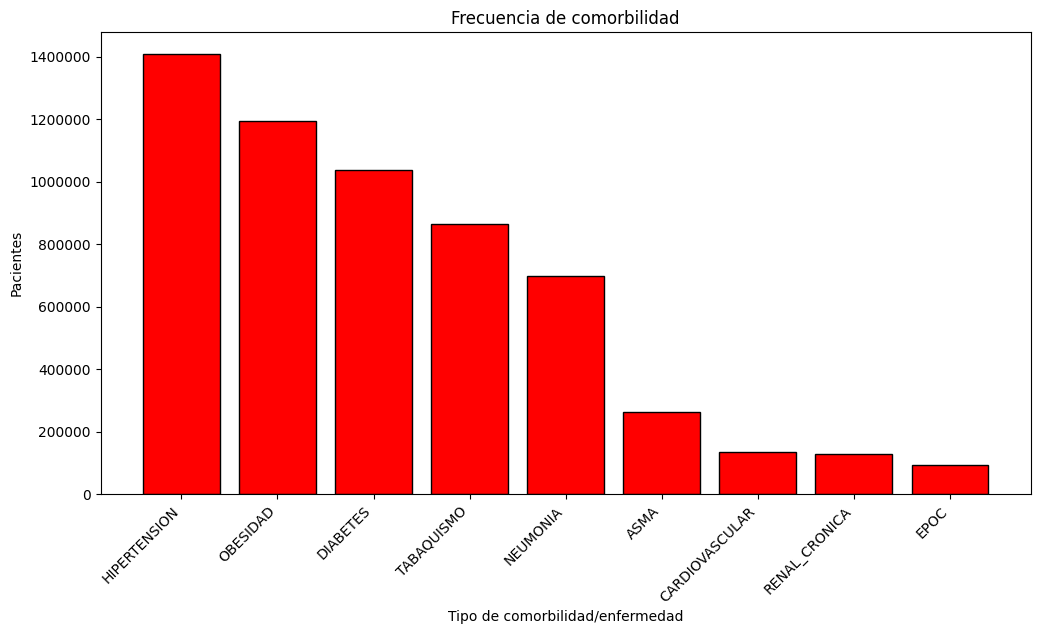

In [10]:
enfermedades={'NEUMONIA','DIABETES','EPOC','ASMA','HIPERTENSION','CARDIOVASCULAR','OBESIDAD','RENAL_CRONICA','TABAQUISMO'}
conteos={}
for enfermedad in enfermedades:
  total_si=(df[enfermedad]=="Si").sum() # se filtra la columna actual donde el valor sea exactamente igual a "Si" y sumamos cuántas filas cumplen la condición
  conteos[enfermedad]=total_si
comorbilidad=pd.Series(conteos).sort_values(ascending=False) #se convierte el diccioario a una serie de pandas y se ordena de mayor a menor
plt.figure(figsize=(12,6))
plt.bar(comorbilidad.index, comorbilidad.values, color='red', edgecolor='black')#los index se vuelven el eje X (las enfermedades) y los values para eje Y (totales)
plt.title('Frecuencia de comorbilidad')
plt.xlabel('Tipo de comorbilidad/enfermedad')
plt.ylabel('Pacientes')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [11]:
total=len(df) #total de registros del data set
enfermedades={'NEUMONIA','DIABETES','EPOC','ASMA','HIPERTENSION','CARDIOVASCULAR','OBESIDAD','RENAL_CRONICA','TABAQUISMO'}
for enfermedad in enfermedades:
  total_si=(df[enfermedad]=="Si").sum() # se filtra la columna actual donde el valor sea exactamente igual a "Si" y sumamos cuántas filas cumplen la condición
  prob=total_si/total #se divide el total de registros que si tienen dicha enfermedad entre el total de registros y eso da la probabilidad
  print("Probabilidad de que un paciente tenga",enfermedad,":",(prob*100),"%")

Probabilidad de que un paciente tenga ASMA : 2.088419728239095 %
Probabilidad de que un paciente tenga DIABETES : 8.21943212206493 %
Probabilidad de que un paciente tenga EPOC : 0.731712683848293 %
Probabilidad de que un paciente tenga HIPERTENSION : 11.142610284439197 %
Probabilidad de que un paciente tenga RENAL_CRONICA : 1.0279563540024792 %
Probabilidad de que un paciente tenga CARDIOVASCULAR : 1.06385892127349 %
Probabilidad de que un paciente tenga TABAQUISMO : 6.847781504700656 %
Probabilidad de que un paciente tenga OBESIDAD : 9.442794688762893 %
Probabilidad de que un paciente tenga NEUMONIA : 5.51852377761494 %


###Probabilidad de que un paciente tenga DIABETES : **8.21943212206493 %**
###Probabilidad de que un paciente tenga RENAL_CRONICA : **1.0279563540024792 %**
###Probabilidad de que un paciente tenga NEUMONIA : **5.51852377761494 %**
###Probabilidad de que un paciente tenga CARDIOVASCULAR : **1.06385892127349 %**
###Probabilidad de que un paciente tenga OBESIDAD : **9.442794688762893 %**
###Probabilidad de que un paciente tenga HIPERTENSION : **11.142610284439197 %**
###Probabilidad de que un paciente tenga EPOC : **0.731712683848293 %**
###Probabilidad de que un paciente tenga TABAQUISMO : **6.847781504700656 %**
###Probabilidad de que un paciente tenga ASMA : **2.088419728239095 %**

In [14]:
estados='ENTIDAD_NAC'
total_por_estado=df.groupby(estados).size() #se agrupa por estado para saber el número total de pacientes registrados en cada entidad
enfermedades=['NEUMONIA','DIABETES','EPOC','ASMA','HIPERTENSION','CARDIOVASCULAR','OBESIDAD','RENAL_CRONICA','TABAQUISMO']
#se filtra renglón por renglón si el paciente tiene "Si" en cualquiera de las columnas seleccionadas
#el método .any(axis=1) funciona como un operador 'O' (OR) a lo largo de las columnas: si encuentra un solo "Si", marca la fila como True
df['TieneComorbilidad']=(df[enfermedades]=="Si").any(axis=1)
#se filtra la tabla dejando solo a los pacientes que dieron True en 'TieneComorbilidad'
#luego se vuelve a agrupar por estado para contar cuántos de ellos tenían enfermedades de base
casos_p_estado=df[df['TieneComorbilidad']].groupby(estados).size()
#se aplica la fórmula de probabilidad condicional dividiendo los casos con comorbilidad entre el total de cada estado
#pandas alinea automáticamente los estados de ambas variables para hacer la división exacta
prob1=casos_p_estado/total_por_estado
#se convierte el resultado (que era una Serie) en un DataFrame limpio usando .reset_index()
df_prob1=prob1.reset_index(name='Probabilidad_Comorbilidad')
#se acomodan los valores de mayor a menor
df_prob1=df_prob1.sort_values(by='Probabilidad_Comorbilidad', ascending=False)
print("Probabilidad de presentar al menos una comorbilidad por estado:")
print(df_prob1)

Probabilidad de presentar al menos una comorbilidad por estado:
             ENTIDAD_NAC  Probabilidad_Comorbilidad
12               Hidalgo                   0.395363
5              Chihuahua                   0.393059
32             Zacatecas                   0.379282
13               Jalisco                   0.378151
25               Sinaloa                   0.371881
26                Sonora                   0.366908
21                Puebla                   0.361167
1        Baja California                   0.356864
3               Campeche                   0.353167
30              Veracruz                   0.345223
17               Nayarit                   0.342253
28            Tamaulipas                   0.339422
11              Guerrero                   0.331800
8                 Colima                   0.328845
22             Querétaro                   0.320600
20                Oaxaca                   0.320518
10            Guanajuato                   0.319199


Probabilidad de que un estado tenga entre 2000 y 3000 casos: 0.5079095196676364
Porcentaje: 50.79%


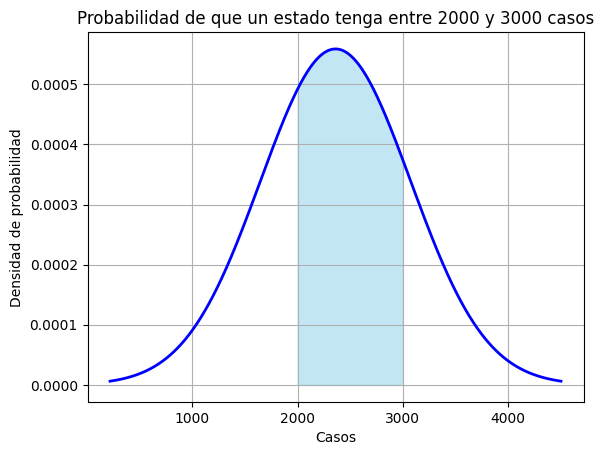

In [13]:
from scipy.stats import norm
import numpy as np
media=2360
desv_std=714
prob_menos_3000=norm.cdf(3000,media,desv_std) #funcion de distribucion acumulativa (cdf) de la distribucion normal para calcular probabilidad de menos de 3000 casos
prob_menos_2000=norm.cdf(2000,media,desv_std)
prob_entre=prob_menos_3000-prob_menos_2000 #diferencia entre la probabilidad de menos de 3000 y menos de 2000 es la probabilidad entre 2000 y 3000
print("Probabilidad de que un estado tenga entre 2000 y 3000 casos:",prob_entre)
print(f"Porcentaje: {prob_entre*100:.2f}%")
#graficar distribucion normal
x=np.linspace(media - 3* desv_std, media + 3* desv_std, 5000)
y=norm.pdf(x,media,desv_std)
plt.plot(x,y, 'b',linewidth=2)
plt.fill_between(x, y, where=((x>= 2000) & (x<=3000)), color='skyblue', alpha=0.5)
plt.title('Probabilidad de que un estado tenga entre 2000 y 3000 casos')
plt.xlabel('Casos')
plt.ylabel('Densidad de probabilidad')
plt.grid(True)
plt.show()

<a href="https://colab.research.google.com/github/spacepirate07/Probabilidad-/blob/main/Unidad6/ProyectoFinalU6.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

###**Interpretacion general**
Después de revisar este data set con más de 12 millones de registros, se pudo descubrir cómo se comportó la pandemia en nuestro país durante cierto periodo de tiempo.

Para empezar, si miramos cómo le fue a la gente con sus pruebas, la categoria mas frecuente correspondio al resultado negativo (46.3%), mientras que los resultados positvos abarcan un 14.05%. Sin embargo, hay un dato que salta a la vista: un 39.62% de las personas se quedó en "esperando resultado" (pendiente de resultado). Esto no es solo un número; nos dice que en los momentos más duros, los laboratorios y hospitales estuvieron saturados y no daban abasto para procesar tantas pruebas, ademas de que genera una incertidumbre sobre si la mayoria de los registros son de casos positivos o negativos. Si vemos esto a lo largo del tiempo, queda claro que el virus no se movió en línea recta, sino que llegó por "olas". Hubo dos picos muy marcados, siendo el del verano de 2021 el más agresivo de todos, probablemente por las nuevas variantes que surgieron durante dicho periodo. Además, la gráfica tiene un sube y baja constante; esto significa que los sábados y domingos se reportaban menos datos y todo se acumulaba para los martes o miércoles.

Por el lado de las edades, la gráfica rompe con la idea de que la mayoría de los registrados eran personas de la tercera edad. En realidad, el grupo que más veces tiene registros en esta base de datos fue la gente joven y adulta, especialmente entre los 25 y 30 años. Esto tiene lógica: es la población que tiene que salir a trabajar, la que más se mueve y, por lo tanto, la que estuvo más expuesta al contagio. Curiosamente, el virus afecto de igual manera tanto a hombres como a mujeres; al ver las barras, la mitad eran hombres y la otra mitad mujeres, un empate casi perfecto.

La gran mayoría de las personas (un 91.4%) se quedaron en casa con cuidados ambulatorios, pero el 8.6% restante tuvo que terminar en el hospital. Aunque parezca un porcentaje pequeño, cuando hablamos de millones de personas, ese 8.6% significó una presión gigantesca para los médicos, ¿y quiénes tenían más probabilidades de acabar ahí? El análisis de las enfermedades nos dio la respuesta: la hipertensión, la obesidad y la diabetes fueron los padecimientos que aparecieron con mayor frecuencia en el data set.

Finalmente, las graficas nos muestran que el peligro no fue igual para todos. Si vemos los números totales, la Ciudad de México y el Estado de México son los que tuvieron mas casos porque ahí vive muchísima gente. Pero cuando se calculo la probabilidad de comorbilidad por estado, hubo una sorpresa: estados como Hidalgo y Chihuahua resultaron tener a las poblaciones más vulnerables, donde casi 4 de cada 10 pacientes ya cargaban con alguna enfermedad antes de contagiarse.